# QAOA under a hardware-job budget — 8 assets on `ibm_fez`

**Dr. Muhammad Faryad** · companion notebook to *"Batched pattern search: QAOA cost measured in
hardware jobs"*

This notebook solves a 8-asset cardinality-constrained portfolio problem
(choose 4 of 8) on IBM hardware, and it treats **one submitted job as the unit of cost**.
Every quantum call is a single job with a single PUB; jobs are submitted **one at a time** and
never in a `Session` or `Batch`, which is the access pattern an open-plan user actually has.

Two optimisers are run head to head under an *identical* budget —
**12 jobs each, 5,120 shots per job**:

| arm | what one job buys |
|---|---|
| **batched pattern search** | 10 parameter vectors × 512 shots each |
| **COBYLA (serial baseline)** | 1 parameter vector × 5,120 shots |

Same jobs, same shots — the only difference is whether the shot budget of a job is spent on
*one* point of the landscape or spread across *10* of them.

Everything below (`P_LAYERS`, `SHOTS`, `N_JOBS`, `ALPHA`, `RADIUS0`, and the penalty `mu`) was
chosen by rehearsing the whole experiment on a noise model of `ibm_fez` — see the tuning summary
in the accompanying notes. **Set `DRY_RUN = True` to rehearse without spending QPU time.**

Predicted metered QPU time for a full run: **≈ 139 s**, hard-capped at
300 s by the ledger in Checkpoint 4.

Requirements: `qiskit>=2.0, qiskit-aer, qiskit-ibm-runtime, matplotlib, scipy`.

---
## Checkpoint 0 — configuration

In [2]:
import json, time, itertools, warnings
from math import comb

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

warnings.filterwarnings("ignore")

# ============================================================
# Everything you may want to change lives in this cell
# ============================================================
DRY_RUN      = False                 # True -> noise-model rehearsal, zero QPU time
ACCOUNT_NAME = "Faryad-free-ibm"      # QiskitRuntimeService(name=...)
BACKEND_NAME = "ibm_fez"

N_ASSETS  = 8                          # qubits
BUDGET    = 4                          # assets to hold
LAMBDA    = 1.652797                # risk aversion   (return factor fixed to 1)
MU        = 9.0                       # constraint penalty (calibrated below)

P_LAYERS  = 3                          # QAOA depth
SHOTS     = 1024                       # shots per candidate parameter vector
N_JOBS    = 10                         # optimisation jobs PER ARM  <-- the cost unit
ALPHA     = 0.5                        # CVaR tail fraction
RADIUS0   = 0.25                       # initial pattern-search step

SHOTS_FINAL  = 8192                  # final read-out job, per arm
QPU_BUDGET_S = 300                  # hard ceiling on metered quantum seconds
SEED         = 1234

N_CAND    = 2 + 4 * P_LAYERS         # candidates in a full pattern-search batch
JOB_SHOTS = N_CAND * SHOTS           # shots in one job -- identical for both arms

rng = np.random.default_rng(SEED)
print(f"{N_ASSETS} assets, choose {BUDGET}: {2**N_ASSETS} bitstrings, "
      f"{comb(N_ASSETS, BUDGET)} feasible")
print(f"p = {P_LAYERS}, {2*P_LAYERS} parameters, {N_CAND} candidates/batch")
print(f"budget: {N_JOBS} jobs x {JOB_SHOTS:,} shots per arm, two arms "
      f"+ 4 closing jobs = {2*N_JOBS+4} jobs")

8 assets, choose 4: 256 bitstrings, 70 feasible
p = 3, 6 parameters, 14 candidates/batch
budget: 10 jobs x 14,336 shots per arm, two arms + 4 closing jobs = 24 jobs


---
## Checkpoint 1 — the classical problem

Binary $x_i \in \{0,1\}$ marks asset $i$ as held. With returns $\mathbf r$, covariance
$\Sigma$, and a cardinality constraint $\sum_i x_i = B$,

$$C(\mathbf x) = \lambda\, \mathbf x^{T}\Sigma\,\mathbf x - \mathbf r^{T}\mathbf x
                 + \mu\left(\sum_i x_i - B\right)^{2}.$$

The instance is the **first 8 assets** of the twelve-asset table, so the 8-, 8-, 10- and
12-asset instances of this study are *nested*: same problem, more assets.

Two hyperparameters are not free choices and are reported as such:

* $\lambda$ is fixed so that, across feasible portfolios, the spread of the risk term equals the
  spread of the return term. Without this, a portfolio problem silently degenerates into "sort by
  return" and QAOA gets credit for solving nothing.
* $\mu$ was scanned on the ideal $p{=}2$ QAOA: large $\mu$ spends Hamiltonian norm on the
  constraint and flattens the objective, small $\mu$ lets infeasible states win.
  $\mu = 9$ sits at the top of that scan and keeps the ground state feasible with a
  9.0x margin over the smallest feasible-ground-state penalty.

With only $2^{8} = 256$ bitstrings we enumerate everything, so every number reported later is
checked against the exact answer.

In [17]:
asset_names = ['Google', 'Intel', 'Nvidia', 'Goldman Sachs', 'ExxonMobil', 'IBM',
               'JPMorgan', 'Bank of America', 'Johnson & Johnson', 'Pfizer',
               'Walmart', 'Amazon']
tickers = ['GOOG', 'INTC', 'NVDA', 'GS', 'XOM', 'IBM', 'JPM', 'BAC', 'JNJ', 'PFE', 'WMT', 'AMZN']
asset_names = tickers

expected_returns_12 = np.array(
    [59.14, 168.17, 28.48, 41.97, 48.07, 12.59, 24.56, 31.27, 46.84, 20.29, 14.46, 23.06])

covariance_12 = np.array(
    [[10.41, 4.95, 2.92, 3.04, -2.16, 1.20, 1.36, 1.29, -0.16, 0.51, 0.21, 5.63],
     [4.95, 62.12, 10.62, 8.27, -3.19, -2.50, 1.97, 1.80, -2.81, -0.11, -1.29, 4.88],
     [2.92, 10.62, 13.48, 5.41, -1.81, 0.12, 1.52, 1.06, -1.55, -0.51, -1.67, 3.69],
     [3.04, 8.27, 5.41, 9.88, -1.54, 0.52, 4.54, 3.72, -0.88, 0.41, -0.84, 2.51],
     [-2.16, -3.19, -1.81, -1.54, 6.51, -0.71, -0.36, -0.43, 0.52, -0.18, 0.41, -1.97],
     [1.20, -2.50, 0.12, 0.52, -0.71, 23.34, 1.66, 2.14, 0.15, 1.70, -1.17, 2.05],
     [1.36, 1.97, 1.52, 4.54, -0.36, 1.66, 4.97, 3.57, 0.09, 0.56, -0.28, 1.27],
     [1.29, 1.80, 1.06, 3.72, -0.43, 2.14, 3.57, 4.50, -0.13, 0.50, 0.08, 1.32],
     [-0.16, -2.81, -1.55, -0.88, 0.52, 0.15, 0.09, -0.13, 3.44, 1.29, 1.37, -0.94],
     [0.51, -0.11, -0.51, 0.41, -0.18, 1.70, 0.56, 0.50, 1.29, 5.58, 0.23, 0.54],
     [0.21, -1.29, -1.67, -0.84, 0.41, -1.17, -0.28, 0.08, 1.37, 0.23, 5.98, -0.89],
     [5.63, 4.88, 3.69, 2.51, -1.97, 2.05, 1.27, 1.32, -0.94, 0.54, -0.89, 11.84]])

expected_returns = expected_returns_12[:N_ASSETS]
covariance_matrix = covariance_12[:N_ASSETS, :N_ASSETS]
names = asset_names[:N_ASSETS]

# --- exhaustive enumeration (Qiskit convention: bit i of the integer == qubit i) ---
N_STATES = 2 ** N_ASSETS
all_bits = (np.arange(N_STATES)[:, None] >> np.arange(N_ASSETS)[None, :]) & 1
quad = np.einsum("ki,ij,kj->k", all_bits, covariance_matrix, all_bits)
lin = all_bits @ expected_returns
viol = (all_bits.sum(1) - BUDGET) ** 2

objective_all = LAMBDA * quad - lin              # penalty-free part
classical_all = objective_all + MU * viol
feasible_mask = all_bits.sum(1) == BUDGET

C_opt = classical_all.min()
opt_index = int(classical_all.argmin())
C_worst_feas = classical_all[feasible_mask].max()
C_mean_uniform = classical_all.mean()
C_mean_feas = classical_all[feasible_mask].mean()

approx_ratio = lambda c: (C_worst_feas - c) / (C_worst_feas - C_opt)

assert feasible_mask[opt_index], "penalty too small: the global minimum is infeasible"
risk_spread = LAMBDA * np.ptp(quad[feasible_mask])
ret_spread = np.ptp(lin[feasible_mask])
print(f"risk spread / return spread = {risk_spread/ret_spread:.3f}   "
      f"(<0.05 would mean we are only sorting by return)")
print(f"global minimum   {C_opt:9.2f}   feasible")
print(f"worst feasible   {C_worst_feas:9.2f}")
print(f"mean over all    {C_mean_uniform:9.2f}   <- the do-nothing baseline")
print(f"mean | feasible  {C_mean_feas:9.2f}   (approximation ratio {approx_ratio(C_mean_feas):.3f})")
print("optimal portfolio:", [names[i] for i in range(N_ASSETS) if all_bits[opt_index, i]])

risk spread / return spread = 1.000   (<0.05 would mean we are only sorting by return)
global minimum     -161.10   feasible
worst feasible       23.32
mean over all       -36.91   <- the do-nothing baseline
mean | feasible     -60.69   (approximation ratio 0.456)
optimal portfolio: ['GOOG', 'INTC', 'XOM', 'BAC']


---
## Checkpoint 2 — Ising form, and the check that it is the same problem

Substituting $x_i = (1 - z_i)/2$ turns $C(\mathbf x)$ into

$$\tilde H = \sum_i h_i Z_i + \sum_{i<j} J_{ij} Z_i Z_j ,\qquad
  C = s\,\tilde H + c,$$

after dropping the identity and rescaling so that $\max|{\rm coeff}| = 1$ — the rescaling matters
because the pattern-search step size and the CVaR tolerance are both expressed in these units, and
they should not have to be re-tuned for every instance size.

The assert below compares the Hamiltonian's diagonal to the classical cost on **all** $2^n$
bitstrings. If it passes, the ground state of $\tilde H$ *is* the optimal portfolio.

In [4]:
def ising_terms(r, C, lam, mu, B):
    """h, J, offset for  lam x'Cx - r'x + mu (sum x - B)^2  under x = (1-z)/2."""
    n = len(r)
    Q = lam * C + mu * np.ones((n, n))
    L = r + 2 * mu * B * np.ones(n)
    offset = mu * B ** 2
    h = np.zeros(n)
    J = np.zeros((n, n))
    for i in range(n):
        offset += Q[i, i] / 2 - L[i] / 2
        h[i] += -Q[i, i] / 2 + L[i] / 2
    for i in range(n):
        for j in range(i + 1, n):
            cij = 2 * Q[i, j]
            offset += cij / 4
            h[i] -= cij / 4
            h[j] -= cij / 4
            J[i, j] += cij / 4
    return h, J, float(offset)


h_raw, J_raw, E_offset = ising_terms(expected_returns, covariance_matrix, LAMBDA, MU, BUDGET)
E_scale = max(np.abs(h_raw).max(), np.abs(J_raw).max())
h, J = h_raw / E_scale, J_raw / E_scale

z = 1 - 2 * all_bits
diag = z @ h
for i in range(N_ASSETS):
    for j in range(i + 1, N_ASSETS):
        diag += J[i, j] * z[:, i] * z[:, j]

to_real = lambda e: E_scale * e + E_offset
to_norm = lambda c: (c - E_offset) / E_scale

max_dev = np.abs(classical_all - to_real(diag)).max()
assert max_dev < 1e-8, f"mapping is wrong, max deviation {max_dev}"
print(f"mapping verified on all {N_STATES} bitstrings (max deviation {max_dev:.1e})")
print(f"offset c = {E_offset:.3f}   scale s = {E_scale:.3f}")
print(f"|+>^n  -> E_norm = 0.000     optimum -> E_norm = {to_norm(C_opt):+.3f}")
print("A run that ends with a POSITIVE E_norm did worse than doing nothing.")

mapping verified on all 256 bitstrings (max deviation 1.3e-13)
offset c = -36.911   scale s = 27.084
|+>^n  -> E_norm = 0.000     optimum -> E_norm = -4.585
A run that ends with a POSITIVE E_norm did worse than doing nothing.


---
## Checkpoint 3 — the noiseless reference and the objective

$\tilde H$ is diagonal, so a QAOA state costs two array operations per layer instead of a full
circuit simulation. This is the *reference*, not the experiment: at every job we will ask what the
current parameters would have produced on a perfect device, and the gap between that and the
measurement is the device's noise penalty.

The optimiser minimises $\mathrm{CVaR}_\alpha$ — the mean energy of the lowest $\alpha$ of the
sampled probability mass. On a noisy device the mean is dominated by the depolarised background,
while the tail still carries the signal, which is why $\alpha < 1$ is standard for hardware QAOA.

In [5]:
def qaoa_probs(params, reps=None):
    """Noiseless QAOA output distribution; params = [beta_0..., gamma_0...]."""
    reps = P_LAYERS if reps is None else reps
    betas, gammas = params[:reps], params[reps:]
    psi = np.ones(N_STATES, dtype=complex) / np.sqrt(N_STATES)
    for k in range(reps):
        psi = psi * np.exp(-1j * gammas[k] * diag)
        psi = psi.reshape([2] * N_ASSETS)
        cb, sb = np.cos(betas[k]), -1j * np.sin(betas[k])
        for q in range(N_ASSETS):
            ax = N_ASSETS - 1 - q
            psi = np.moveaxis(psi, ax, 0)
            a, b = psi[0].copy(), psi[1].copy()
            psi[0], psi[1] = cb * a + sb * b, sb * a + cb * b
            psi = np.moveaxis(psi, 0, ax)
        psi = psi.reshape(-1)
    return np.abs(psi) ** 2


ORDER = np.argsort(diag)            # states sorted by energy, computed once
E_SORTED = diag[ORDER]


def cvar(probs, alpha=None):
    """Mean energy of the lowest `alpha` of the probability mass."""
    alpha = ALPHA if alpha is None else alpha
    p = probs[ORDER]
    cum = np.cumsum(p)
    k = min(int(np.searchsorted(cum, alpha)) + 1, p.size)
    w = p[:k].copy()
    w[-1] -= max(cum[k - 1] - alpha, 0.0)
    return float(E_SORTED[:k] @ w / w.sum()) if w.sum() > 0 else float(E_SORTED[0])


def quality(probs):
    """The three numbers reported for any distribution over bitstrings."""
    fm = float(probs[feasible_mask].sum())
    cond = probs * feasible_mask / max(fm, 1e-15)
    return dict(feas_mass=fm,
                mean_cost=float(classical_all @ probs),
                mean_cost_feas=float(classical_all @ cond),
                ratio=float(approx_ratio(classical_all @ cond)),
                p_opt=float(probs[opt_index]),
                p_opt_feas=float(cond[opt_index]))


uniform = np.full(N_STATES, 1 / N_STATES)
print("uniform |+>^n baseline:", {k: round(v, 4) for k, v in quality(uniform).items()})

uniform |+>^n baseline: {'feas_mass': 0.2734, 'mean_cost': -36.9107, 'mean_cost_feas': -60.6931, 'ratio': 0.4555, 'p_opt': 0.0039, 'p_opt_feas': 0.0143}


---
## Checkpoint 4 — the circuit: a SWAP network, not the transpiler's guess

The cost Hamiltonian is a **complete graph** — every pair of assets is coupled — while `ibm_fez`
is heavy-hex. Handing `qaoa_ansatz` to the preset pass manager therefore produces a routing
solution whose depth is set by the transpiler's SWAP heuristic and changes with the seed.

Instead we place the 8 qubits on a single physical **chain** and realise all
$\binom{8}{2} = 28$ couplings with an odd–even transposition network: at every step,
neighbouring pairs interact and then swap, so after $n$ steps every pair has met exactly once. The
gate count is then *deterministic*:

$$\#\,\text{2q gates} = 3p\binom{n}{2} = 168,
  \qquad \text{2q depth} = 3pn = 48.$$

The 3 comes from emitting $\mathrm{RZZ}(\theta)\cdot\mathrm{SWAP}$ by hand as
`cx(a,b); rz(θ,b); cx(b,a); cx(a,b)`. It is worth doing by hand: Qiskit's two-qubit block
consolidation cannot fuse gates that carry unbound `Parameter`s, so leaving this to the transpiler
costs five entangling gates per pair instead of three.

The cell below builds both versions and prints the comparison — that table is a result in itself.

In [6]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.circuit import ParameterVector


def qaoa_swap_network(h, J, reps):
    """QAOA on a linear chain. Returns (circuit, perm) with perm[position] = logical qubit."""
    n = len(h)
    betas, gammas = ParameterVector("b", reps), ParameterVector("g", reps)
    qr, cr = QuantumRegister(n, "q"), ClassicalRegister(n, "c")
    qc = QuantumCircuit(qr, cr)
    qc.h(range(n))
    perm = list(range(n))
    for layer in range(reps):
        g, be = gammas[layer], betas[layer]
        for pos in range(n):
            if h[perm[pos]]:
                qc.rz(2 * g * h[perm[pos]], pos)
        for step in range(n):                       # odd-even transposition network
            for pos in range(step % 2, n - 1, 2):
                a, b = perm[pos], perm[pos + 1]
                w = J[min(a, b), max(a, b)]
                qc.cx(pos, pos + 1)                 # RZZ(2 g w) . SWAP  in 3 CX
                qc.rz(2 * g * w, pos + 1)
                qc.cx(pos + 1, pos)
                qc.cx(pos, pos + 1)
                perm[pos], perm[pos + 1] = b, a
        qc.rx(2 * be, range(n))
    for pos in range(n):
        qc.measure(pos, perm[pos])                  # clbit index == logical qubit index
    return qc, perm


circuit, perm = qaoa_swap_network(h, J, P_LAYERS)
print(f"logical circuit: {circuit.count_ops().get('cx', 0)} CX, "
      f"{3 * P_LAYERS * N_ASSETS * (N_ASSETS - 1) // 2} expected")

logical circuit: 252 CX, 252 expected


In [7]:
# --- the circuit really is QAOA: compare against the exact state vector ---
from qiskit.quantum_info import Statevector

_test = np.array([0.31, -0.62] * P_LAYERS)[:2 * P_LAYERS]
_bind = {p: v for p, v in zip(sorted(circuit.parameters, key=lambda p: p.name),
                              list(_test[:P_LAYERS]) + list(_test[P_LAYERS:]))}
_probs_phys = Statevector.from_instruction(
    circuit.remove_final_measurements(inplace=False).assign_parameters(_bind)).probabilities()
_idx = np.arange(N_STATES)
_bits = (_idx[:, None] >> np.arange(N_ASSETS)[None, :]) & 1
_log = np.zeros(N_STATES, dtype=int)
for pos in range(N_ASSETS):
    _log |= _bits[:, pos] << perm[pos]
_probs = np.zeros(N_STATES)
_probs[_log] = _probs_phys
assert np.abs(_probs - qaoa_probs(_test)).max() < 1e-9, "SWAP network is not QAOA"
print("SWAP-network circuit verified against the exact QAOA state vector "
      f"(max deviation {np.abs(_probs - qaoa_probs(_test)).max():.1e})")

SWAP-network circuit verified against the exact QAOA state vector (max deviation 4.2e-17)


---
## Checkpoint 5 — backend, qubit chain, and the error budget

The chain is chosen by a beam search over simple paths of the coupling map, minimising
$\sum -\log(1-\varepsilon)$ over the CZ and readout errors on the path, i.e. the best
8-qubit line the device has **on the day you run it**. It is passed as an explicit
`initial_layout` and the cell asserts that the pass manager did not move it.

`optimization_level=1` is deliberate: the layout and routing decisions have already been made by
hand, and level 3 would only re-synthesise blocks it cannot fuse (they carry unbound parameters)
while risking a different layout.

In [8]:
if DRY_RUN:
    from qiskit_ibm_runtime.fake_provider import FakeFez
    backend = FakeFez()
    print("DRY RUN — rehearsing on a noise model of ibm_fez, no QPU time will be used")
else:
    from qiskit_ibm_runtime import QiskitRuntimeService
    service = QiskitRuntimeService(name=ACCOUNT_NAME)
    backend = service.backend(BACKEND_NAME)
    print(f"{backend.name}: {backend.num_qubits} qubits, "
          f"{backend.status().pending_jobs} jobs queued")


def best_chain(backend, n, beam=3000):
    """Lowest-total-error simple path of n physical qubits."""
    t = backend.target
    cz = {e: (p.error if p and p.error is not None else 0.01) for e, p in t["cz"].items()}
    ro = {q[0]: (p.error if p and p.error is not None else 0.02) for q, p in t["measure"].items()}
    adj = {}
    for (a, b), e in cz.items():
        adj.setdefault(a, []).append((b, e))
    w = lambda e: -np.log(max(1e-6, 1 - e))
    paths = [([q], w(ro.get(q, 0.02))) for q in range(backend.num_qubits)]
    for _ in range(n - 1):
        nxt = []
        for path, cost in paths:
            for b, e in adj.get(path[-1], []):
                if b not in path:
                    nxt.append((path + [b], cost + w(e) + w(ro.get(b, 0.02))))
        nxt.sort(key=lambda t: t[1])
        seen, keep = set(), []
        for path, cost in nxt:
            key = (path[-1], frozenset(path))
            if key not in seen:
                seen.add(key)
                keep.append((path, cost))
            if len(keep) >= beam:
                break
        paths = keep
    return min(paths, key=lambda t: t[1])


chain, chain_cost = best_chain(backend, N_ASSETS)
print(f"chain {chain}   surviving amplitude along the chain {np.exp(-chain_cost):.3f}")

ibm_fez: 156 qubits, 2 jobs queued
chain [124, 123, 136, 143, 144, 145, 146, 147]   surviving amplitude along the chain 0.934


In [9]:
from qiskit.transpiler import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=1, backend=backend,
                                  initial_layout=chain, seed_transpiler=42)
isa_circuit = pm.run(circuit)

used = sorted({isa_circuit.find_bit(q).index for inst in isa_circuit.data for q in inst.qubits
               if inst.operation.name in ("cz", "measure")})
assert set(used) <= set(chain), f"the pass manager moved the layout: {used} vs {chain}"

n2q = sum(1 for inst in isa_circuit.data if inst.operation.name == "cz")
d2q = isa_circuit.depth(lambda inst: inst.operation.name == "cz")
cz_err = float(np.median([p.error for p in backend.target["cz"].values()
                          if p and p.error is not None]))
print(f"SWAP network + level 1 : {n2q:4d} two-qubit gates, two-qubit depth {d2q:3d}")
print(f"error budget           : (1 - {cz_err:.4f})^{n2q} = {(1-cz_err)**n2q:.3f} "
      f"of the amplitude survives")

# --- what the transpiler does on its own, for the record ---
from qiskit.circuit.library import qaoa_ansatz
from qiskit.quantum_info import SparsePauliOp

terms = []
for i in range(N_ASSETS):
    s = ["I"] * N_ASSETS; s[N_ASSETS - 1 - i] = "Z"; terms.append(("".join(s), h[i]))
for i in range(N_ASSETS):
    for j in range(i + 1, N_ASSETS):
        s = ["I"] * N_ASSETS; s[N_ASSETS-1-i] = "Z"; s[N_ASSETS-1-j] = "Z"
        terms.append(("".join(s), J[i, j]))
generic = qaoa_ansatz(SparsePauliOp.from_list(terms), reps=P_LAYERS)
generic.measure_all()
isa_generic = generate_preset_pass_manager(optimization_level=3, backend=backend,
                                           seed_transpiler=42).run(generic)
g2q = sum(1 for inst in isa_generic.data if inst.operation.name == "cz")
gd2q = isa_generic.depth(lambda inst: inst.operation.name == "cz")
print(f"qaoa_ansatz + level 3  : {g2q:4d} two-qubit gates, two-qubit depth {gd2q:3d}")
print(f"SWAP network is {g2q/n2q:.2f}x cheaper in gates and {gd2q/d2q:.2f}x shallower")
circuit_report = dict(n2q=n2q, depth2q=d2q, depth=isa_circuit.depth(),
                      generic_n2q=g2q, generic_depth2q=gd2q, cz_error=cz_err,
                      chain=list(map(int, chain)))

SWAP network + level 1 :  252 two-qubit gates, two-qubit depth  72
error budget           : (1 - 0.0026)^252 = 0.513 of the amplitude survives
qaoa_ansatz + level 3  :  344 two-qubit gates, two-qubit depth 174
SWAP network is 1.37x cheaper in gates and 2.42x shallower


---
## Checkpoint 6 — one job at a time, on a ledger

`submit()` is the only function in this notebook that touches the QPU. It sends **one job with one
PUB**; the PUB carries `rows` parameter vectors, so a batched iteration and a serial iteration cost
exactly one job each. There is no `Session` and no `Batch`: jobs are queued individually, which is
the access mode being costed.

The ledger is the point of the paper. Before every submission it predicts the metered quantum
seconds; after two real jobs it stops trusting the model and switches to the **measured**
per-shot rate reported by `job.metrics()`. If the next job would break `QPU_BUDGET_S` it refuses to
submit rather than silently overrunning your account.

In `DRY_RUN` mode `submit()` samples from a calibrated depolarising twin of `ibm_fez` instead of
the device: the ideal distribution mixed with the uniform distribution at strength $\eta$, then
independent readout flips. $\eta = 0.206$ for this size and depth was fitted against full
`AerSimulator.from_backend(FakeFez)` simulations (it reproduces Aer's CVaR to about 0.1 in
normalised units). It is a rehearsal, not a prediction — a fake backend has no crosstalk model.

In [10]:
ETA_TWIN = 0.2055      # calibrated against AerSimulator.from_backend(FakeFez)
READOUT_ERR = float(np.mean([backend.target["measure"][(q,)].error for q in chain]))

REP_DELAY = 2.5e-4          # ibm_fez default, seconds per shot
CIRCUIT_S = 1e-9 * (84 * d2q + 24 * isa_circuit.depth() + 1560)   # rough per-shot circuit time
JOB_OVERHEAD_S = 3.0

n_jobs_used, shots_used, qpu_used = 0, 0, 0.0
qpu_per_shot = 1.4 * (REP_DELAY + CIRCUIT_S)      # model; replaced by measurement after 2 jobs
job_log = []


def predict_qpu(n_shots):
    return qpu_per_shot * n_shots + JOB_OVERHEAD_S


def twin_sample(x, shots):
    """Rehearsal device: depolarised ideal distribution + readout flips, then shot noise."""
    p = (1 - ETA_TWIN) * qaoa_probs(x) + ETA_TWIN / N_STATES
    p = p.reshape([2] * N_ASSETS)
    for q in range(N_ASSETS):
        ax = N_ASSETS - 1 - q
        p = np.moveaxis(p, ax, 0)
        a, b = p[0].copy(), p[1].copy()
        p[0], p[1] = (1 - READOUT_ERR) * a + READOUT_ERR * b, READOUT_ERR * a + (1 - READOUT_ERR) * b
        p = np.moveaxis(p, 0, ax)
    p = np.maximum(p.reshape(-1), 0)
    return rng.multinomial(shots, p / p.sum()) / shots


def submit(params, shots=SHOTS, tag=""):
    """ONE job, ONE PUB, len(params) parameter rows. Returns a list of distributions."""
    global n_jobs_used, shots_used, qpu_used, qpu_per_shot
    params = np.atleast_2d(np.asarray(params, float))
    rows, total = params.shape[0], params.shape[0] * shots
    predicted = predict_qpu(total)
    if qpu_used + predicted > QPU_BUDGET_S:
        raise RuntimeError(f"refusing to submit '{tag}': {qpu_used:.1f} s used, "
                           f"this job needs ~{predicted:.1f} s, cap is {QPU_BUDGET_S:.0f} s")
    t0 = time.time()
    stamps = {}
    if DRY_RUN:
        dists = [twin_sample(x, shots) for x in params]
        job_id, measured = "dry-run", predicted
    else:
        pub_params = np.zeros_like(params)
        order = [p.name for p in isa_circuit.parameters]
        for i, nm in enumerate([f"b[{k}]" for k in range(P_LAYERS)]
                               + [f"g[{k}]" for k in range(P_LAYERS)]):
            pub_params[:, order.index(nm)] = params[:, i]
        job = sampler.run([(isa_circuit, pub_params)], shots=shots)
        data = job.result()[0].data.c
        dists = []
        for k in range(rows):                       # NEVER call get_int_counts() unindexed:
            cnt = data[k].get_int_counts()          # with no row index it merges all rows
            d_ = np.zeros(N_STATES)
            d_[list(cnt.keys())] = np.array(list(cnt.values())) / shots
            dists.append(d_)
        job_id = job.job_id()
        try:
            met = job.metrics()
            measured = float(met["usage"]["quantum_seconds"])
            stamps = {k: str(v) for k, v in met.get("timestamps", {}).items()}
        except Exception:
            measured = predicted
    n_jobs_used += 1
    shots_used += total
    qpu_used += measured
    job_log.append(dict(tag=tag, job=n_jobs_used, id=job_id, rows=rows, shots=shots,
                        qpu_predicted=predicted, qpu_measured=measured,
                        wall=time.time() - t0, timestamps=stamps,
                        params=params.tolist(),
                        counts=[{int(i): int(round(d_[i] * shots))
                                 for i in np.nonzero(d_)[0]} for d_ in dists]))
    if not DRY_RUN:
        print(f"    job {n_jobs_used:2d} [{tag}] id={job_id}  {measured:5.2f} qpu s  "
              f"{time.time()-t0:5.0f} s wall  (total {qpu_used:6.1f} / {QPU_BUDGET_S:.0f} s)")
    if not DRY_RUN and n_jobs_used >= 2:            # trust the device over the model
        qpu_per_shot = max(1e-9, (qpu_used - JOB_OVERHEAD_S * n_jobs_used) / shots_used)
    return dists


if not DRY_RUN:
    from qiskit_ibm_runtime import SamplerV2
    sampler = SamplerV2(mode=backend)               # job mode: no Session, no Batch
    sampler.options.dynamical_decoupling.enable = True
    sampler.options.twirling.enable_gates = True    # Pauli twirling costs no extra shots
    sampler.options.twirling.enable_measure = True

print(f"predicted cost of one optimisation job : {predict_qpu(JOB_SHOTS):6.1f} s")
print(f"predicted cost of the whole notebook   : "
      f"{(2*N_JOBS+1)*predict_qpu(JOB_SHOTS) + 3*predict_qpu(SHOTS_FINAL):6.1f} s "
      f"over {2*N_JOBS+4} jobs   (cap {QPU_BUDGET_S:.0f} s)")

predicted cost of one optimisation job :    8.3 s
predicted cost of the whole notebook   :  193.1 s over 24 jobs   (cap 300 s)


---
## Checkpoint 7 — batched pattern search

Pattern search is the one derivative-free method whose entire iteration is known *before* any
function value comes back: the incumbent, the $2\times 2p$ axial probes at the current radius, and
one momentum probe along the last accepted step. That is what makes it a job-level algorithm —
10 landscape points, one job, one round trip through the queue.

Everything else follows the standard compass-search rules: accept the best probe only if it beats
the incumbent by more than the shot-noise tolerance (half a standard error of the measured energy),
grow the radius by 1.3 on success, shrink by 0.6 on failure. The tolerance is what keeps the search
from chasing noise; without it, at 512 shots per candidate the incumbent moves on almost every
iteration and the run never settles.

In [11]:
class BatchedPatternSearch:
    """One iteration = one job: every candidate is known before any value comes back."""

    def __init__(self, x0, radius):
        self.x = np.array(x0, float)
        self.x_prev = np.array(x0, float)
        self.r = float(radius)

    def ask(self):
        cands = [self.x.copy()]                       # row 0: the incumbent
        for i in range(self.x.size):
            for sgn in (+1, -1):
                y = self.x.copy()
                y[i] += sgn * self.r
                cands.append(y)
        step = self.x - self.x_prev
        if np.linalg.norm(step) > 1e-9:
            cands.append(self.x + step)                # momentum probe
        return np.array(cands)

    def tell(self, cands, values, tol):
        j = int(np.argmin(values))
        if j != 0 and values[j] < values[0] - tol:
            self.x_prev, self.x = self.x.copy(), cands[j].copy()
            self.r = min(self.r * 1.3, np.pi / 2)
            return True
        self.r = max(self.r * 0.6, 0.02)
        return False


# adiabatic-inspired linear ramp: |gamma| rises, beta falls
k = np.arange(1, P_LAYERS + 1)
x0 = np.concatenate([0.5 * (1 - (k - 0.5) / P_LAYERS), -0.5 * k / P_LAYERS])
print("start (beta..., gamma...) =", np.round(x0, 4))
print(f"noiseless CVaR at the start: {cvar(qaoa_probs(x0)):+.4f}")

start (beta..., gamma...) = [ 0.4167  0.25    0.0833 -0.1667 -0.3333 -0.5   ]
noiseless CVaR at the start: -3.4594


In [12]:
opt = BatchedPatternSearch(x0, RADIUS0)
bps = dict(cvar=[], best_cvar=[], ideal_ratio=[], ideal_cvar=[], radius=[], moved=[],
           x=[], cand_cvar=[], cand_mean=[], cand_feas=[])
best_b = dict(cvar=np.inf, x=x0.copy())
first_batch = None

for it in range(N_JOBS):
    cands = opt.ask()
    shots_each = JOB_SHOTS // len(cands)              # per-job shots held fixed
    if first_batch is None:
        first_batch = (cands.copy(), shots_each)
    dists = submit(cands, shots=shots_each, tag=f"bps{it+1}")
    values = np.array([cvar(d) for d in dists])
    bps["cand_cvar"].append(values.tolist())
    bps["cand_mean"].append([float(diag @ d) for d in dists])
    bps["cand_feas"].append([float(d[feasible_mask].sum()) for d in dists])

    j = int(np.argmin(values))
    if values[j] < best_b["cvar"]:
        best_b.update(cvar=float(values[j]), x=cands[j].copy())

    p0 = dists[0]                                     # shot-noise scale from the incumbent row
    sd = np.sqrt(max(0.0, p0 @ diag ** 2 - (diag @ p0) ** 2))
    moved = opt.tell(cands, values, 0.5 * sd / np.sqrt(shots_each))

    bps["cvar"].append(float(values.min()))
    bps["best_cvar"].append(float(best_b["cvar"]))
    bps["ideal_ratio"].append(quality(qaoa_probs(opt.x))["ratio"])
    bps["ideal_cvar"].append(cvar(qaoa_probs(opt.x)))
    bps["radius"].append(float(opt.r))
    bps["moved"].append(bool(moved))
    bps["x"].append(opt.x.tolist())
    print(f"job {it+1:2d}/{N_JOBS}  CVaR {values.min():+.4f}  best {best_b['cvar']:+.4f}  "
          f"r {opt.r:.3f}  {'moved ' if moved else 'shrink'}  "
          f"ideal ratio {bps['ideal_ratio'][-1]:.3f}  [{qpu_used:5.1f} s]")

print(f"\nbatched pattern search: {N_JOBS} jobs, best CVaR {best_b['cvar']:+.4f}, "
      f"x = {np.round(best_b['x'], 4)}")

    job  1 [bps1] id=da3d88botlns7399hm80   8.33 qpu s     20 s wall  (total    8.3 / 300 s)
job  1/10  CVaR -3.3930  best -3.3930  r 0.325  moved   ideal ratio 0.847  [  8.3 s]
    job  2 [bps2] id=da3d8djotlns7399hmdg   8.33 qpu s     79 s wall  (total   16.7 / 300 s)
job  2/10  CVaR -3.5984  best -3.5984  r 0.423  moved   ideal ratio 0.902  [ 16.7 s]
    job  3 [bps3] id=da3d9161vhnc73fjmgj0   8.33 qpu s     15 s wall  (total   25.0 / 300 s)
job  3/10  CVaR -3.6898  best -3.6898  r 0.254  shrink  ideal ratio 0.902  [ 25.0 s]
    job  4 [bps4] id=da3d94uaa69c739ig5bg   8.33 qpu s     34 s wall  (total   33.3 / 300 s)
job  4/10  CVaR -3.6319  best -3.6898  r 0.330  moved   ideal ratio 0.896  [ 33.3 s]
    job  5 [bps5] id=da3d9de1vhnc73fjmh50   8.33 qpu s    309 s wall  (total   41.7 / 300 s)
job  5/10  CVaR -3.6213  best -3.6898  r 0.198  shrink  ideal ratio 0.896  [ 41.7 s]
    job  6 [bps6] id=da3dbqk3jnrc73aeu090   8.33 qpu s     69 s wall  (total   50.0 / 300 s)
job  6/10  CVaR -

---
## Checkpoint 8 — the serial control arm, same jobs, same shots

The control is **COBYLA**, the strongest of `COBYLA`, `SPSA`, `Nelder-Mead` and `Powell`
on the FakeFez rehearsal of this instance. It gets exactly 12 jobs — one function
evaluation each — and each of those evaluations is measured with the *whole* 5,120-shot
budget of a job, so the two arms consume identical quantum resources by both metrics.

This is the strict version of the comparison. The only asymmetry left is what the shots are spent
on: 10 points at 512 shots, or one point at 5,120.

In [13]:
serial = dict(values=[], best=[], x=[], ideal_ratio=[], ideal_cvar=[])
best_s = dict(cvar=np.inf, x=x0.copy())


class _Budget(Exception):
    pass


def serial_objective(x):
    if len(serial["values"]) >= N_JOBS:
        raise _Budget
    d = submit(np.atleast_2d(x), shots=JOB_SHOTS, tag=f"ser{len(serial['values'])+1}")[0]
    v = cvar(d)
    if v < best_s["cvar"]:
        best_s.update(cvar=float(v), x=np.array(x, float))
    serial["values"].append(float(v))
    serial["best"].append(float(best_s["cvar"]))
    serial["x"].append(list(map(float, x)))
    serial["ideal_ratio"].append(quality(qaoa_probs(np.array(x, float)))["ratio"])
    serial["ideal_cvar"].append(cvar(qaoa_probs(np.array(x, float))))
    print(f"job {len(serial['values']):2d}/{N_JOBS}  CVaR {v:+.4f}  best {best_s['cvar']:+.4f}  "
          f"ideal ratio {serial['ideal_ratio'][-1]:.3f}  [{qpu_used:5.1f} s]")
    return v


try:
    minimize(serial_objective, x0, method="COBYLA",
             options={'maxiter': N_JOBS + 5, 'rhobeg': RADIUS0})
except _Budget:
    pass

print(f"\nCOBYLA: {len(serial['values'])} jobs, best CVaR {best_s['cvar']:+.4f}, "
      f"x = {np.round(best_s['x'], 4)}")

    job 11 [ser1] id=da3dd9m1vhnc73fjmm70   8.33 qpu s     16 s wall  (total   91.6 / 300 s)
job  1/10  CVaR -2.8654  best -2.8654  ideal ratio 0.721  [ 91.6 s]
    job 12 [ser2] id=da3dddm1vhnc73fjmmc0   8.33 qpu s     23 s wall  (total  100.0 / 300 s)
job  2/10  CVaR -2.9075  best -2.9075  ideal ratio 0.723  [100.0 s]
    job 13 [ser3] id=da3ddjbotlns7399ht60   8.33 qpu s     25 s wall  (total  108.3 / 300 s)
job  3/10  CVaR -2.9910  best -2.9910  ideal ratio 0.768  [108.3 s]
    job 14 [ser4] id=da3ddpjotlns7399hthg   8.33 qpu s     26 s wall  (total  116.6 / 300 s)
job  4/10  CVaR -3.4360  best -3.4360  ideal ratio 0.849  [116.6 s]
    job 15 [ser5] id=da3de0e1vhnc73fjmn80   8.33 qpu s     22 s wall  (total  125.0 / 300 s)
job  5/10  CVaR -3.0513  best -3.4360  ideal ratio 0.822  [125.0 s]
    job 16 [ser6] id=da3de5u1vhnc73fjmni0   8.33 qpu s     26 s wall  (total  133.3 / 300 s)
job  6/10  CVaR -2.9193  best -3.4360  ideal ratio 0.701  [133.3 s]
    job 17 [ser7] id=da3decbotlns7

---
## Checkpoint 9 — final read-out, the $\gamma = 0$ noise floor, and a drift check

Four jobs close the experiment.

* A deep read-out at each arm's best parameters.
* A control at $\gamma = 0$ with $\beta$ unchanged. This runs a circuit of *identical depth and
  gate count* whose ideal output is exactly $|+\rangle^{\otimes n}$, so whatever structure survives
  in it is the device's noise floor and not something QAOA found. Every claim below is only as good
  as the distance between the QAOA read-out and this control.
* A repeat of the **first** pattern-search batch, submitted last. The two arms run one after the
  other, so a device that drifts over the half hour would flatter whichever arm ran in the better
  conditions. Comparing this repeat against job 1 puts a number on that.

In [14]:
read_bps = submit(np.atleast_2d(best_b["x"]), shots=SHOTS_FINAL, tag="readout_bps")[0]
read_ser = submit(np.atleast_2d(best_s["x"]), shots=SHOTS_FINAL, tag="readout_serial")[0]
x_ctrl = best_b["x"].copy()
x_ctrl[P_LAYERS:] = 0.0
read_ctrl = submit(np.atleast_2d(x_ctrl), shots=SHOTS_FINAL, tag="control_gamma0")[0]

# drift: the very first pattern-search batch, re-run last
_c, _s = first_batch
drift_now = [cvar(d) for d in submit(_c, shots=_s, tag="drift_repeat")]
drift = dict(first=bps["cand_cvar"][0], repeat=drift_now,
             shift=float(np.mean(np.array(drift_now) - np.array(bps["cand_cvar"][0]))))
print(f"drift check: mean CVaR shift over the run = {drift['shift']:+.4f} "
      f"(shot-noise scale is a few 0.01)\n")

rows = [("batched pattern search", read_bps),
        ("serial baseline", read_ser),
        ("noiseless, BPS params", qaoa_probs(best_b["x"])),
        ("noiseless, serial params", qaoa_probs(best_s["x"])),
        ("gamma = 0 control", read_ctrl),
        ("uniform |+>^n", uniform)]

hdr = (f"{'':<26}{'feas mass':>10}{'mean cost':>11}{'mean|feas':>11}"
       f"{'p(opt)|feas':>12}{'ratio':>8}")
print(hdr); print("-" * len(hdr))
final = {}
for name, d in rows:
    q = quality(d)
    final[name] = q
    print(f"{name:<26}{q['feas_mass']:>10.4f}{q['mean_cost']:>11.2f}{q['mean_cost_feas']:>11.2f}"
          f"{q['p_opt_feas']:>12.4f}{q['ratio']:>8.3f}")
print("-" * len(hdr))
print(f"post-selecting on Hamming weight {BUDGET} keeps {final['batched pattern search']['feas_mass']:.1%} "
      "of the shots and is free error mitigation: any other bitstring is provably an error.")
print(f"\n{n_jobs_used} jobs, {shots_used:,} shots, {qpu_used:.1f} s of metered QPU time")

    job 21 [readout_bps] id=da3df8uaa69c739igdlg   6.05 qpu s     19 s wall  (total  172.7 / 300 s)
    job 22 [readout_serial] id=da3dfdjotlns7399hvsg   6.05 qpu s     22 s wall  (total  178.7 / 300 s)
    job 23 [control_gamma0] id=da3dfj43jnrc73aeu5t0   6.05 qpu s     16 s wall  (total  184.8 / 300 s)
    job 24 [drift_repeat] id=da3dfmrotlns7399i0ag   8.33 qpu s     26 s wall  (total  193.1 / 300 s)
drift check: mean CVaR shift over the run = +0.0426 (shot-noise scale is a few 0.01)

                           feas mass  mean cost  mean|feas p(opt)|feas   ratio
------------------------------------------------------------------------------
batched pattern search        0.4280     -94.22    -119.01      0.2738   0.772
serial baseline               0.3484     -88.97    -113.23      0.2078   0.740
noiseless, BPS params         0.5884    -134.35    -145.90      0.4644   0.918
noiseless, serial params      0.3902    -121.40    -146.32      0.4434   0.920
gamma = 0 control             0.2

---
## Checkpoint 10 — the figures

Left: what the device reported, per job. Right: the *exact* approximation ratio the incumbent
parameters would give on a noiseless device, recomputed classically at every job — this is the
curve that says whether the optimiser is learning the landscape or fitting the noise, and it is the
figure the paper is built on.

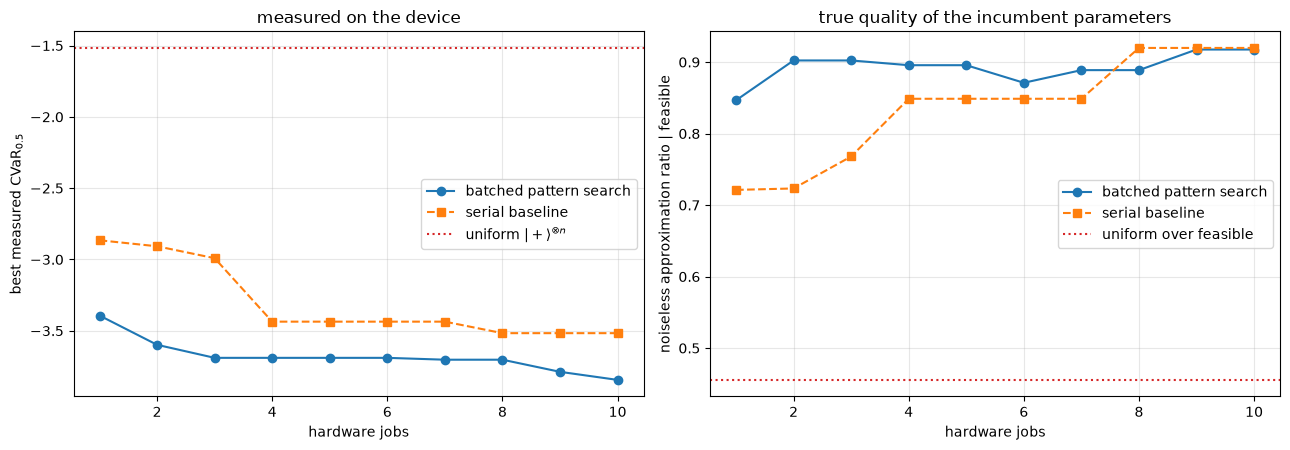

In [15]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
jb = np.arange(1, len(bps["best_cvar"]) + 1)
js = np.arange(1, len(serial["best"]) + 1)

a1.plot(jb, bps["best_cvar"], "o-", label="batched pattern search")
a1.plot(js, serial["best"], "s--", label="serial baseline")
a1.axhline(cvar(uniform), color="tab:red", ls=":", label=r"uniform $|+\rangle^{\otimes n}$")
a1.set_xlabel("hardware jobs"); a1.set_ylabel(f"best measured CVaR$_{{{ALPHA}}}$")
a1.set_title("measured on the device"); a1.legend(); a1.grid(alpha=.3)

a2.plot(jb, bps["ideal_ratio"], "o-", label="batched pattern search")
a2.plot(js, np.maximum.accumulate(serial["ideal_ratio"]), "s--", label="serial baseline")
a2.axhline(approx_ratio(C_mean_feas), color="tab:red", ls=":", label="uniform over feasible")
a2.set_xlabel("hardware jobs"); a2.set_ylabel("noiseless approximation ratio | feasible")
a2.set_title("true quality of the incumbent parameters"); a2.legend(); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

ranked by ibm_fez                                   exact ranking
1.   -161.1 GOOG, INTC, XOM, BAC                       -161.1 GOOG, INTC, XOM, BAC
2.   -152.6 GOOG, INTC, XOM, JPM                       -152.6 GOOG, INTC, XOM, JPM
3.   -139.4 GOOG, INTC, GS, XOM                        -139.4 GOOG, INTC, GS, XOM
4.   -131.9 INTC, XOM, JPM, BAC                        -131.9 INTC, XOM, JPM, BAC
5.   -126.7 GOOG, INTC, XOM, IBM                       -126.7 GOOG, INTC, XOM, IBM

the true optimum ranks 1 of 70 on the device


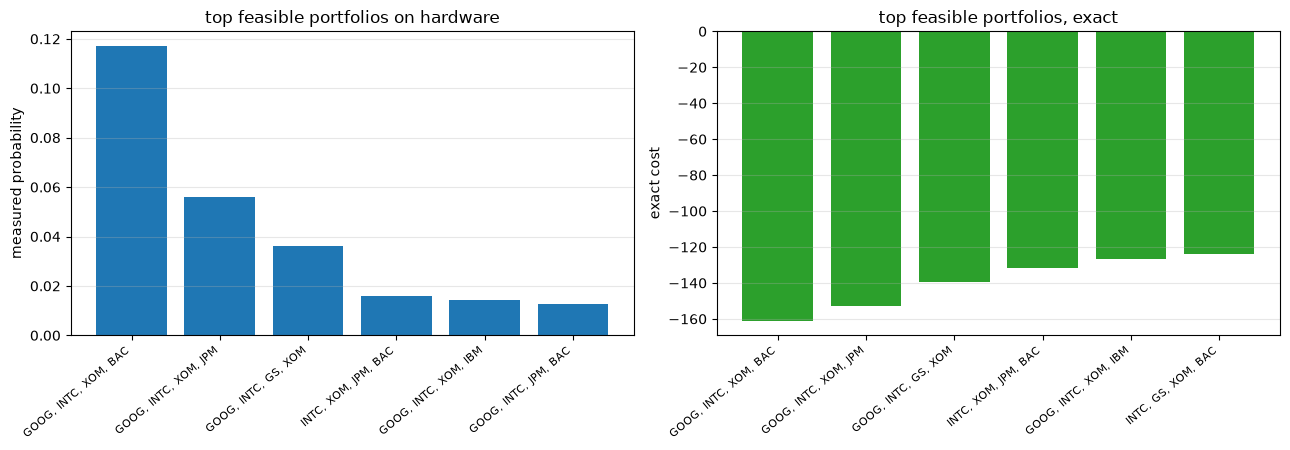

In [18]:
# top feasible portfolios: what the device ranked, versus the exact ranking
feas_idx = np.where(feasible_mask)[0]
dev_rank = feas_idx[np.argsort(-read_bps[feas_idx])]
exact_rank = feas_idx[np.argsort(classical_all[feas_idx])]
sel = lambda s: ", ".join(names[i][:13] for i in range(N_ASSETS) if all_bits[s, i])

print(f"{'ranked by ibm_fez':<52}{'exact ranking'}")
for r in range(5):
    a, b = dev_rank[r], exact_rank[r]
    print(f"{r+1}. {classical_all[a]:8.1f} {sel(a):<40} {classical_all[b]:8.1f} {sel(b)}")
rank_of_opt = int(np.where(dev_rank == opt_index)[0][0]) + 1
print(f"\nthe true optimum ranks {rank_of_opt} of {len(feas_idx)} on the device")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
top = dev_rank[:6]
a1.bar(range(len(top)), read_bps[top], color="tab:blue")
a1.set_xticks(range(len(top)))
a1.set_xticklabels([sel(s) for s in top], rotation=40, ha="right", fontsize=8)
a1.set_ylabel("measured probability"); a1.set_title("top feasible portfolios on hardware")
a1.grid(axis="y", alpha=.3)

top_e = exact_rank[:6]
a2.bar(range(len(top_e)), classical_all[top_e], color="tab:green")
a2.set_xticks(range(len(top_e)))
a2.set_xticklabels([sel(s) for s in top_e], rotation=40, ha="right", fontsize=8)
a2.set_ylabel("exact cost"); a2.set_title("top feasible portfolios, exact")
a2.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

---
## Checkpoint 11 — save everything

One JSON file with the full job log (including the IBM job ids), both optimisation traces, every
measured distribution and all final metrics. **Send `{OUT}` back along with the executed
notebook** — the figures and tables of the paper are built from it, and nothing else is needed.

In [19]:
OUT = f"qaoa_jobs_8assets_{'dryrun' if DRY_RUN else BACKEND_NAME}.json"

payload = dict(
    provenance=dict(n_assets=N_ASSETS, budget=BUDGET, dry_run=DRY_RUN,
                    backend=str(backend.name), account=ACCOUNT_NAME,
                    date=time.strftime("%Y-%m-%d %H:%M:%S"),
                    lam=LAMBDA, mu=MU, p=P_LAYERS, shots=SHOTS, job_shots=JOB_SHOTS,
                    n_jobs_per_arm=N_JOBS, alpha=ALPHA, radius0=RADIUS0,
                    shots_final=SHOTS_FINAL, seed=SEED,
                    serial_method="COBYLA", eta_twin=ETA_TWIN,
                    readout_err=READOUT_ERR),
    circuit=circuit_report,
    problem=dict(names=names, expected_returns=expected_returns.tolist(),
                 covariance=covariance_matrix.tolist(),
                 C_opt=float(C_opt), C_worst_feas=float(C_worst_feas),
                 C_mean_uniform=float(C_mean_uniform), C_mean_feas=float(C_mean_feas),
                 opt_index=opt_index, E_scale=float(E_scale), E_offset=float(E_offset)),
    ledger=dict(jobs=n_jobs_used, shots=shots_used, qpu_seconds=qpu_used, log=job_log),
    bps=dict(trace=bps, best_x=best_b["x"].tolist(), best_cvar=best_b["cvar"]),
    serial=dict(trace=serial, best_x=best_s["x"].tolist(), best_cvar=best_s["cvar"]),
    readouts=dict(bps=read_bps.tolist(), serial=read_ser.tolist(), control=read_ctrl.tolist()),
    drift=drift,
    final=final)

with open(OUT, "w") as f:
    json.dump(payload, f)
print(f"wrote {OUT}  ({len(json.dumps(payload))/1e6:.2f} MB)")
print(f"jobs {n_jobs_used}   shots {shots_used:,}   metered QPU {qpu_used:.1f} s")

wrote qaoa_jobs_8assets_ibm_fez.json  (0.41 MB)
jobs 24   shots 325,612   metered QPU 193.1 s
